# KNN 實作（整合整理版）

這份 Notebook 以原版的教學流程為主，並補上較完整的機器學習實務觀念，包括：

- 更穩定的資料切分：`random_state`、`stratify`
- `StandardScaler` 標準化
- KNN 重要參數說明
- train / test accuracy 比較
- confusion matrix、classification report
- 不同 `k` 值的表現觀察
- Bias / Variance 與 overfitting / underfitting 的對應
- KNN 決策邊界視覺化

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Step1. 下載資料

In [4]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("target names:", iris.target_names)

X shape: (150, 4)
y shape: (150,)
target names: ['setosa' 'versicolor' 'virginica']


## Step2. 區分訓練集與測試集

這裡補上兩個常見的重要設定：

- `random_state=42`：讓每次切分結果可重現
- `stratify=y`：讓訓練集與測試集中的類別比例更接近原始資料分布

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (105, 4)
X_test : (45, 4)


### 補充：標準化（StandardScaler）

KNN 是依靠「距離」來判斷鄰居，因此若不同 feature 的尺度差很多，較大的數值範圍可能會主導距離計算。

例如：
- 花萼長度若落在 1 ~ 10
- 某個特徵若落在 1 ~ 1000

則第二個特徵會對距離影響得更大。

因此，KNN 通常建議進行標準化。

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("標準化後的前 3 筆訓練資料：")
print(X_train_scaled[:3])

標準化後的前 3 筆訓練資料：
[[-0.90045861 -1.22024754 -0.4419858  -0.13661044]
 [ 0.38036614 -1.87955796  0.40282929  0.38029394]
 [-0.90045861  1.63676428 -1.2868009  -1.17041921]]


## Step3. 建模

### KNN 重要參數

- **`n_neighbors`**：K 值，代表看最近的幾個鄰居來決定分類  
  - K 小（如 1~5）容易對局部資料敏感 → 容易 overfitting  
  - K 大（如 20+）容易過度平均 → 容易 underfitting

- **`weights`**：鄰居投票方式  
  - `'uniform'`：每個鄰居權重一樣  
  - `'distance'`：距離越近，權重越高

- **`algorithm`**：搜尋鄰居的方法  
  - `'auto'` / `'brute'` / `'kd_tree'` / `'ball_tree'`

- **`p`**：Minkowski distance 的參數  
  - `p=1`：曼哈頓距離  
  - `p=2`：歐幾里得距離（最常見）

In [7]:
clf = KNeighborsClassifier(
    n_neighbors=3,
    p=2,
    weights='distance',
    algorithm='auto'
)

clf.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Step4. 預測

In [8]:
y_pred = clf.predict(X_test_scaled)
y_pred

array([2, 1, 1, 1, 2, 2, 1, 1, 0, 2, 0, 0, 2, 2, 0, 2, 1, 0, 0, 0, 1, 0,
       1, 2, 2, 1, 1, 1, 1, 0, 1, 2, 1, 0, 2, 0, 0, 0, 0, 1, 1, 0, 1, 2,
       1])

## Step5. 準確程度評估

除了只看一個 `score()`，也可以一起比較：

- 測試集 accuracy
- 訓練集 accuracy
- confusion matrix
- classification report

In [9]:
test_acc = clf.score(X_test_scaled, y_test)
train_acc = clf.score(X_train_scaled, y_train)

print("Test Accuracy :", round(test_acc, 3))
print("Train Accuracy:", round(train_acc, 3))
print("Gap           :", round(train_acc - test_acc, 3))

Test Accuracy : 0.933
Train Accuracy: 1.0
Gap           : 0.067


In [10]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Confusion Matrix:
[[15  0  0]
 [ 0 15  0]
 [ 0  3 12]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.83      1.00      0.91        15
   virginica       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



### 觀察 train / test accuracy 的意義

- **train 很高、test 明顯較低**  
  → 模型可能太貼近訓練資料，屬於 **overfitting / high variance**

- **train 和 test 都不高**  
  → 模型可能太簡單，屬於 **underfitting / high bias**

- **train 與 test 都不錯，而且差距不大**  
  → 通常代表模型的泛化能力較穩定

## Step6. 尋找合適的 K

原版是用最直接的方法觀察不同 K 值的表現，這個方式很適合初學時建立直覺。

這裡我們保留原本精神，但同時觀察：

- `test accuracy`
- `train accuracy`

這樣更容易看出：
- K 太小時，模型是否太貼近訓練資料
- K 太大時，模型是否過度平均

In [11]:
train_accuracy = []
test_accuracy = []

k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_train_pred = knn.predict(X_train_scaled)
    y_test_pred = knn.predict(X_test_scaled)

    train_accuracy.append(metrics.accuracy_score(y_train, y_train_pred))
    test_accuracy.append(metrics.accuracy_score(y_test, y_test_pred))

best_k = list(k_range)[np.argmax(test_accuracy)]
best_score = max(test_accuracy)

print("最佳 k（以本次 test accuracy 來看）:", best_k)
print("最佳 test accuracy:", round(best_score, 3))

最佳 k（以本次 test accuracy 來看）: 9
最佳 test accuracy: 0.956


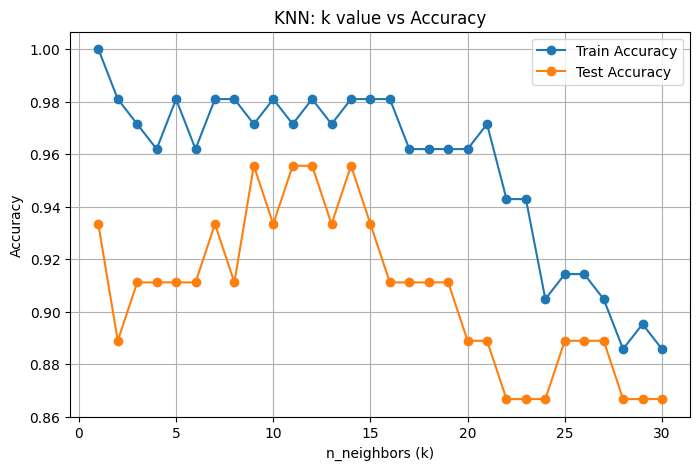

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, train_accuracy, marker='o', label='Train Accuracy')
plt.plot(k_range, test_accuracy, marker='o', label='Test Accuracy')
plt.xlabel("n_neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN: k value vs Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### K 值圖形解讀

- **K 很小（如 k=1）**  
  - train accuracy 常常很高  
  - 但 test accuracy 不一定同樣高  
  - 表示模型可能對局部資料和雜訊太敏感  
  - → **high variance / overfitting**

- **K 適中**  
  - train 與 test accuracy 較平衡  
  - 通常是較好的泛化位置

- **K 很大**  
  - 邊界會更平滑  
  - 若 train / test accuracy 都下降  
  - 表示模型可能過度簡化  
  - → **high bias / underfitting**

## Bias / Variance 重點整理

| 面向 | Bias（偏差） | Variance（變異） |
|------|-------------|----------------|
| 核心問題 | 模型是否偏離真實答案 | 模型是否對資料過度敏感 |
| 白話理解 | 平均預測 vs 真實值的差距 | 每次訓練結果是否大幅變動 |
| 本質 | 模型假設過於簡單 | 模型過度貼近資料細節 |
| 對應問題 | Underfitting | Overfitting |
| KNN 對應 | K 大 | K 小 |

### 一句話總結

- **Bias**：模型太簡單，抓不到資料規律  
- **Variance**：模型太複雜，太容易受訓練資料波動影響  

因此在 KNN 中：

- **K 小** → 高 variance → 容易 overfitting  
- **K 大** → 高 bias → 容易 underfitting

## Step7. 決策邊界視覺化

為了方便畫 2D 圖，這裡只取 iris 的前兩個特徵來觀察 KNN 的決策邊界。

這一段的目的主要是：
- 看模型複雜度改變時，邊界長相如何變化
- 不是追求最佳分數，而是幫助理解 high bias / high variance

In [13]:
X_vis = iris.data[:, :2]
y_vis = iris.target

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y_vis,
    test_size=0.3,
    random_state=42,
    stratify=y_vis
)

scaler_vis = StandardScaler()
X_train_vis_scaled = scaler_vis.fit_transform(X_train_vis)
X_test_vis_scaled = scaler_vis.transform(X_test_vis)

In [14]:
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.title(title)
    plt.show()

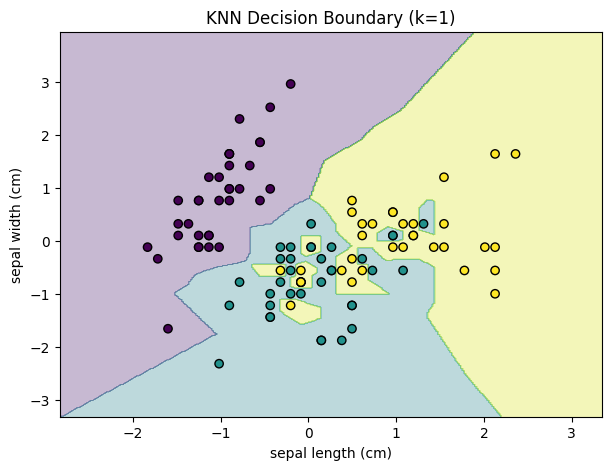

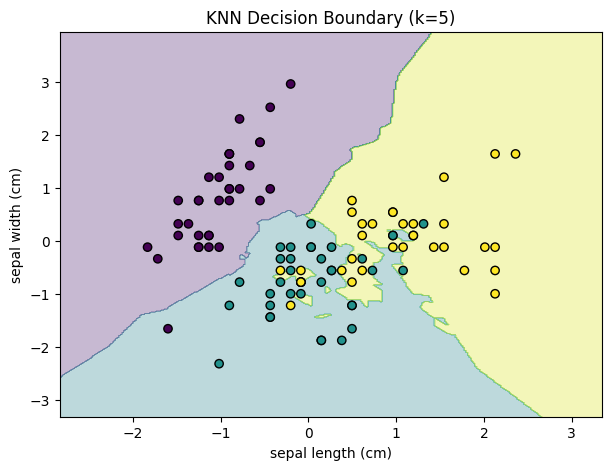

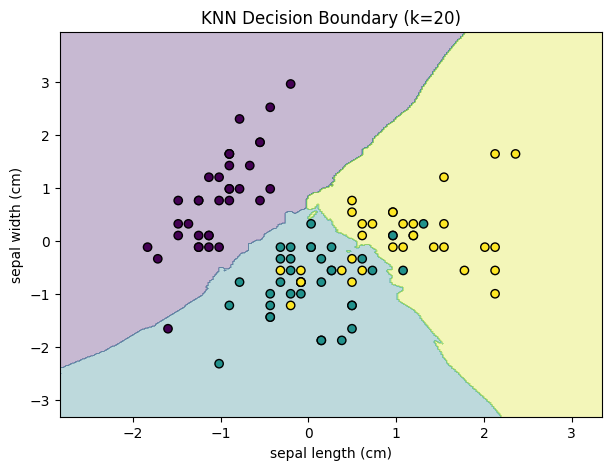

In [15]:
for k in [1, 5, 20]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_vis_scaled, y_train_vis)
    plot_decision_boundary(model, X_train_vis_scaled, y_train_vis, f"KNN Decision Boundary (k={k})")

### 決策邊界觀察

- **k=1**：邊界通常更碎、更鋸齒，表示模型非常貼近局部資料  
- **k=5**：邊界通常比 k=1 平滑，常是較合理的折衷點  
- **k=20**：邊界更平滑，但若太平滑也可能忽略局部特徵

這正是 KNN 中 bias / variance tradeoff 的視覺化表現。

## 本 Notebook 小結

這份 KNN Notebook 保留了原版的學習順序：

1. 載入資料  
2. 切分資料  
3. 建模  
4. 預測  
5. 評估  
6. 找 K 值  

並補上了更完整的觀察角度：

- 為什麼 KNN 要做標準化
- 為什麼不能只看單一 accuracy
- 為什麼 K 小容易 overfitting
- Bias / Variance 和 K 值之間的對應
- 如何從決策邊界圖理解模型複雜度